In [1]:
import astropy
from astropy.io import fits
import bagpipes as pipes
import pathlib
import os
import numpy as np

Bagpipes: Latex turned off in rcParams, plots may look strange.


In [ ]:
JADES_File_Path = pathlib.Path('../JADES/catalogs').expanduser()

In [3]:
for file in JADES_File_Path.glob('*.fits'):
    with astropy.io.fits.open(file) as hdul:
        data = hdul[5].data
        print(hdul.info())

Filename: ../JADES/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      63   ()      
  1  FILTERS       1 BinTableHDU     83   27R x 12C   [6A, E, E, E, E, E, E, E, E, E, E, E]   
  2  FLAG          1 BinTableHDU    308   181144R x 87C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  3  SIZE          1 BinTableHDU    101   181144R x 18C   [J, D, D, D, D, D, D, K, K, K, K, D, D, D, D, D, D, D]   
  4  CIRC          1 BinTableHDU   1631   181144R x 528C   [J, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E

In [ ]:
fits_path = '../JADES/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits'

In [25]:
import numpy as np
from astropy.io import fits

with fits.open(fits_path) as hdul:
    circ_data = hdul[5].data
    photoz_data = hdul[11].data

    # 1. 建立ID映射
    id_circ = circ_data["ID"].astype(int)
    id_photoz = photoz_data["ID"].astype(int)
    common_ids, idx_c, idx_p = np.intersect1d(id_circ, id_photoz, return_indices=True)

    # 2. 准备计算所有有效波段的 SNR
    # final_valid_names 是你之前对齐好的滤光片列表
    all_snrs = []
    for band in final_valid_names:
        f = circ_data[f"{band}_CIRC3"][idx_c]
        e = circ_data[f"{band}_CIRC3_e"][idx_c]
        all_snrs.append(f / (e + 1e-8))

    snr_array = np.array(all_snrs) # 形状: (波段数, 星系数)

    # 3. 筛选准则：
    # - 官方红移在 3 < z < 7 (确保 Lyman break 在观测范围内)
    # - 计算有多少个波段的 SNR > 15
    # - 计算这些波段的平均 SNR
    z_ml = photoz_data["z_ml"][idx_p]
    z_mask = (z_ml > 3) & (z_ml < 7)

    # 统计每个星系有多少个波段 SNR > 15
    high_snr_count = np.sum(snr_array > 15, axis=0)
    # 计算所有波段的平均 SNR
    mean_snr = np.nanmean(snr_array, axis=0)

    # 综合评分：优先考虑高 SNR 波段数量多的，其次看平均 SNR
    score = high_snr_count * 1000 + mean_snr

    # 在符合红移范围的星系中找分值最高的
    best_idx = np.where(z_mask)[0][np.nanargmax(score[z_mask])]

    target_id = int(common_ids[best_idx])
    target_z = z_ml[best_idx]

    print(f"🌟 找到多波段高质量星系 ID: {target_id}")
    print(f"📊 官方红移估算: {target_z:.3f}")
    print(f"🔥 SNR > 15 的波段数量: {high_snr_count[best_idx]}")
    print(f"📈 平均信噪比: {mean_snr[best_idx]:.2f}")

    # 打印前 5 个 SNR 最好的波段
    sorted_snr_indices = np.argsort(snr_array[:, best_idx])[::-1]
    print("各波段表现：")
    for i in sorted_snr_indices[:8]:
        print(f"   {final_valid_names[i]}: SNR = {snr_array[i, best_idx]:.2f}")

🌟 找到多波段高质量星系 ID: 1189881
📊 官方红移估算: 6.914
🔥 SNR > 15 的波段数量: 25
📈 平均信噪比: 2237.94
各波段表现：
   F277W: SNR = 5490.93
   F444W: SNR = 5300.25
   F356W: SNR = 4836.61
   F410M: SNR = 4003.89
   F150W: SNR = 3616.30
   F115W: SNR = 3424.29
   F335M: SNR = 3087.19
   F090W: SNR = 2987.47


/var/folders/qg/whd2wk_d369bbmyz8mslcfww0000gn/T/ipykernel_55485/2879791408.py:33: RuntimeWarning: Mean of empty slice
  mean_snr = np.nanmean(snr_array, axis=0)


In [6]:
import os
from astropy.io import fits

# 1. 设置路径
filter_dir = "my_filters"
current_dir = os.getcwd()

# 2. 从 FITS 文件中获取原始波段顺序（非常重要，必须对应）
with fits.open(fits_path) as hdul:
    # 假设 hdul[1] 是滤光片信息表
    raw_filter_names = hdul[1].data["BAND"]
    # 转换为字符串并统一大写
    raw_filter_names = [str(n).upper() for n in raw_filter_names]

# 3. 扫描本地文件夹，只保留下载成功的滤光片
valid_filter_names = []
valid_filter_paths = []

print("正在同步本地滤光片文件...")

for name in raw_filter_names:
    # 检查本地是否存在对应的 .res 文件
    res_file = f"{name}.res"
    res_path = os.path.join(current_dir, filter_dir, res_file)

    if os.path.exists(res_path):
        valid_filter_names.append(name)
        valid_filter_paths.append(res_path)
        print(f"✅ 已加载本地文件: {res_file}")
    else:
        # 这些通常是之前下载失败的 HST 波段或特殊波段
        print(f"⚠️ 跳过(本地无文件): {name}")

print(f"\n同步完成！共计 {len(valid_filter_names)} 个有效滤光片。")
print(f"有效列表名称: {valid_filter_names}")

正在同步本地滤光片文件...
✅ 已加载本地文件: F070W.res
✅ 已加载本地文件: F090W.res
✅ 已加载本地文件: F115W.res
✅ 已加载本地文件: F150W.res
✅ 已加载本地文件: F162M.res
✅ 已加载本地文件: F182M.res
✅ 已加载本地文件: F200W.res
✅ 已加载本地文件: F210M.res
✅ 已加载本地文件: F277W.res
✅ 已加载本地文件: F300M.res
✅ 已加载本地文件: F335M.res
✅ 已加载本地文件: F356W.res
✅ 已加载本地文件: F410M.res
✅ 已加载本地文件: F430M.res
✅ 已加载本地文件: F444W.res
✅ 已加载本地文件: F460M.res
✅ 已加载本地文件: F770W.res
✅ 已加载本地文件: F1280W.res
✅ 已加载本地文件: F435W.res
✅ 已加载本地文件: F606W.res
✅ 已加载本地文件: F775W.res
✅ 已加载本地文件: F814W.res
✅ 已加载本地文件: F850LP.res
✅ 已加载本地文件: F105W.res
✅ 已加载本地文件: F125W.res
✅ 已加载本地文件: F140W.res
✅ 已加载本地文件: F160W.res

同步完成！共计 27 个有效滤光片。
有效列表名称: ['F070W', 'F090W', 'F115W', 'F150W', 'F162M', 'F182M', 'F200W', 'F210M', 'F277W', 'F300M', 'F335M', 'F356W', 'F410M', 'F430M', 'F444W', 'F460M', 'F770W', 'F1280W', 'F435W', 'F606W', 'F775W', 'F814W', 'F850LP', 'F105W', 'F125W', 'F140W', 'F160W']


In [ ]:
import os
from astropy.io import fits

filter_dir = "my_filters"
current_dir = os.getcwd()

# 1. 获取 FITS 表中所有的列名
with fits.open(fits_path) as hdul:
    all_columns = hdul[5].columns.names  # 获取所有列名
    raw_bands = hdul[1].data["BAND"]     # 获取原始波段名
    raw_bands = [str(n).upper() for n in raw_bands]

# 2. 重新生成有效清单
final_valid_names = []
final_valid_paths = []

print("正在严格对齐本地文件与 FITS 列名...")

for name in raw_bands:
    res_path = os.path.join(current_dir, filter_dir, f"{name}.res")

    # 检查 A: 本地是否有 .res 文件
    file_exists = os.path.exists(res_path)

    # 检查 B: FITS 表里是否有对应的 CIRC3 列
    # 如果是 MIRI 波段（F770W及以上），CIRC3 可能不存在，尝试匹配其他列
    circ_col = f"{name}_CIRC3"
    col_exists = circ_col in all_columns

    if file_exists and col_exists:
        final_valid_names.append(name)
        final_valid_paths.append(res_path)
        print(f"✅ 匹配成功: {name} (使用列 {circ_col})")
    elif file_exists and not col_exists:
        # 如果有文件但没 CIRC3，检查是否有基础 FLUX 列
        if f"{name}_FLUX" in all_columns:
            # 这里你可以决定是否使用基础 FLUX 列，或者干脆跳过
            # 建议跳过以保持所有波段孔径一致性
            print(f"⚠️ 跳过: {name} (本地有文件但表中无 _CIRC3 列)")
        else:
            print(f"❌ 跳过: {name} (表中完全找不到该波段数据)")
    else:
        print(f"⚠️ 跳过: {name} (本地无 .res 文件)")

print(f"\n对齐完成！最终参与拟合的波段数量: {len(final_valid_names)}")

正在严格对齐本地文件与 FITS 列名...
✅ 匹配成功: F070W (使用列 F070W_CIRC3)
✅ 匹配成功: F090W (使用列 F090W_CIRC3)
✅ 匹配成功: F115W (使用列 F115W_CIRC3)
✅ 匹配成功: F150W (使用列 F150W_CIRC3)
✅ 匹配成功: F162M (使用列 F162M_CIRC3)
✅ 匹配成功: F182M (使用列 F182M_CIRC3)
✅ 匹配成功: F200W (使用列 F200W_CIRC3)
✅ 匹配成功: F210M (使用列 F210M_CIRC3)
✅ 匹配成功: F277W (使用列 F277W_CIRC3)
✅ 匹配成功: F300M (使用列 F300M_CIRC3)
✅ 匹配成功: F335M (使用列 F335M_CIRC3)
✅ 匹配成功: F356W (使用列 F356W_CIRC3)
✅ 匹配成功: F410M (使用列 F410M_CIRC3)
✅ 匹配成功: F430M (使用列 F430M_CIRC3)
✅ 匹配成功: F444W (使用列 F444W_CIRC3)
✅ 匹配成功: F460M (使用列 F460M_CIRC3)
❌ 跳过: F770W (表中完全找不到该波段数据)
❌ 跳过: F1280W (表中完全找不到该波段数据)
✅ 匹配成功: F435W (使用列 F435W_CIRC3)
✅ 匹配成功: F606W (使用列 F606W_CIRC3)
✅ 匹配成功: F775W (使用列 F775W_CIRC3)
✅ 匹配成功: F814W (使用列 F814W_CIRC3)
✅ 匹配成功: F850LP (使用列 F850LP_CIRC3)
✅ 匹配成功: F105W (使用列 F105W_CIRC3)
✅ 匹配成功: F125W (使用列 F125W_CIRC3)
✅ 匹配成功: F140W (使用列 F140W_CIRC3)
✅ 匹配成功: F160W (使用列 F160W_CIRC3)

对齐完成！最终参与拟合的波段数量: 25


In [26]:
def load_jades_multi_high(ID):
    # 提取数字 ID
    numeric_id = int(''.join(filter(str.isdigit, str(ID))))

    with fits.open(fits_path) as hdul:
        data = hdul[5].data
        ids_in_table = data["ID"].astype(int)
        idx = np.where(ids_in_table == numeric_id)[0][0]

        fluxes, errors = [], []
        for band in final_valid_names:
            col_f, col_e = f"{band}_CIRC3", f"{band}_CIRC3_e"

            # nJy -> uJy
            f_uJy = data[col_f][idx] / 1000.0
            e_uJy = data[col_e][idx] / 1000.0

            # Bagpipes 绘图函数要求至少有一个波段流量 > 0
            # 即使是 Lyman break 以下的非探测，也给一个极小的正数
            if f_uJy <= 0:
                fluxes.append(1e-5)
            else:
                fluxes.append(f_uJy)

            errors.append(max(e_uJy, 1e-6))

    return np.c_[fluxes, errors]


Bagpipes: fitting object 1189881

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 1      | 0        | 0        | 40000    | N/A    | 40000 | -89376864

Completed in 42.8 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
dust:Av                        0.625      2.000      3.352
nebular:logU                  -3.684     -3.005     -2.325
redshift                       2.392      7.451     12.601
sfh:age                        2.372      7.526     12.629
sfh:massformed                 7.953     10.001     12.035
sfh:metallicity                0.408      1.253      2.092
sfh:tau                        1.681      5.051      8.428




/opt/anaconda3/envs/dustcurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:124: RuntimeWarning: divide by zero encountered in log10
  self.stellar_mass = np.log10(np.sum(self.live_frac_grid*self.ceh.grid))
/opt/anaconda3/envs/dustcurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:125: RuntimeWarning: divide by zero encountered in log10
  self.formed_mass = np.log10(np.sum(self.ceh.grid))
/opt/anaconda3/envs/dustcurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:140: RuntimeWarning: invalid value encountered in scalar divide
  self.mass_weighted_age /= np.sum(self.sfh*self.age_widths)
/opt/anaconda3/envs/dustcurve/lib/python3.11/site-packages/bagpipes/models/star_formation_history.py:149: RuntimeWarning: invalid value encountered in divide
  self.mass_weighted_zmet /= np.sum(self.live_frac_grid*self.ceh.grid)
/opt/anaconda3/envs/dustcurve/lib/python3.11/site-packages/bagpipes/models/model_galaxy.py:588: Runtim

ValueError: zero-size array to reduction operation minimum which has no identity

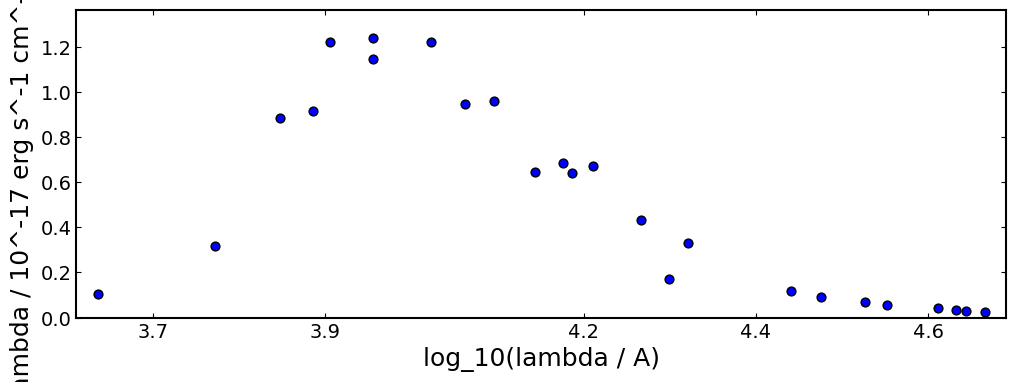

In [28]:
import bagpipes as pipes

# 1. 强制换个新 ID 避开缓存
fit_id = f"{target_id}"

# 2. 初始化 Galaxy
galaxy = pipes.galaxy(fit_id, load_jades_multi_high,
                      spectrum_exists=False,
                      filt_list=final_valid_paths)

# 3. 拟合配置 (稍微放宽 Av 范围，高 SNR 星系通常尘埃较多)
fit_instructions = {
    "redshift": (0.0, 15.0),
    "sfh": {
        "type": "exp",
        "tau": (0.1, 10.),
        "age": (0.01, 15.),
        "massformed": (7., 13.),
        "metallicity": (0.01, 2.5)
    },
    "dust": {"type": "Calzetti", "Av": (0., 4.0)},
    "nebular": {"logU": (-4., -2.)}
}

# 4. 运行拟合 (增加 n_live 让高质量数据的后验更精细)
fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=True, sampler='nautilus', n_live=400)

# 5. 绘图
from bagpipes.plotting.plot_spectrum_posterior import plot_spectrum_posterior
from bagpipes.plotting.plot_corner import plot_corner
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

# 绘制 SED 拟合图
fig1 = plot_spectrum_posterior(fit, show=True)
# 绘制参数分布图
fig2 = plot_corner(fit, show=True)

ValueError: zero-size array to reduction operation minimum which has no identity

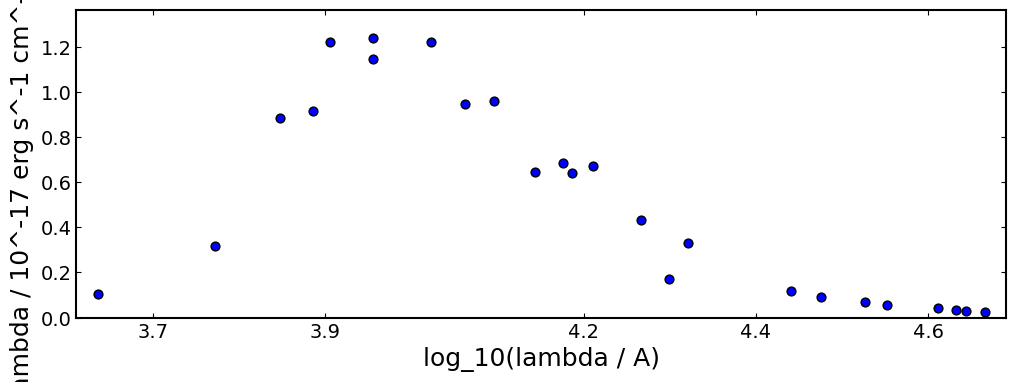

In [29]:
fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)


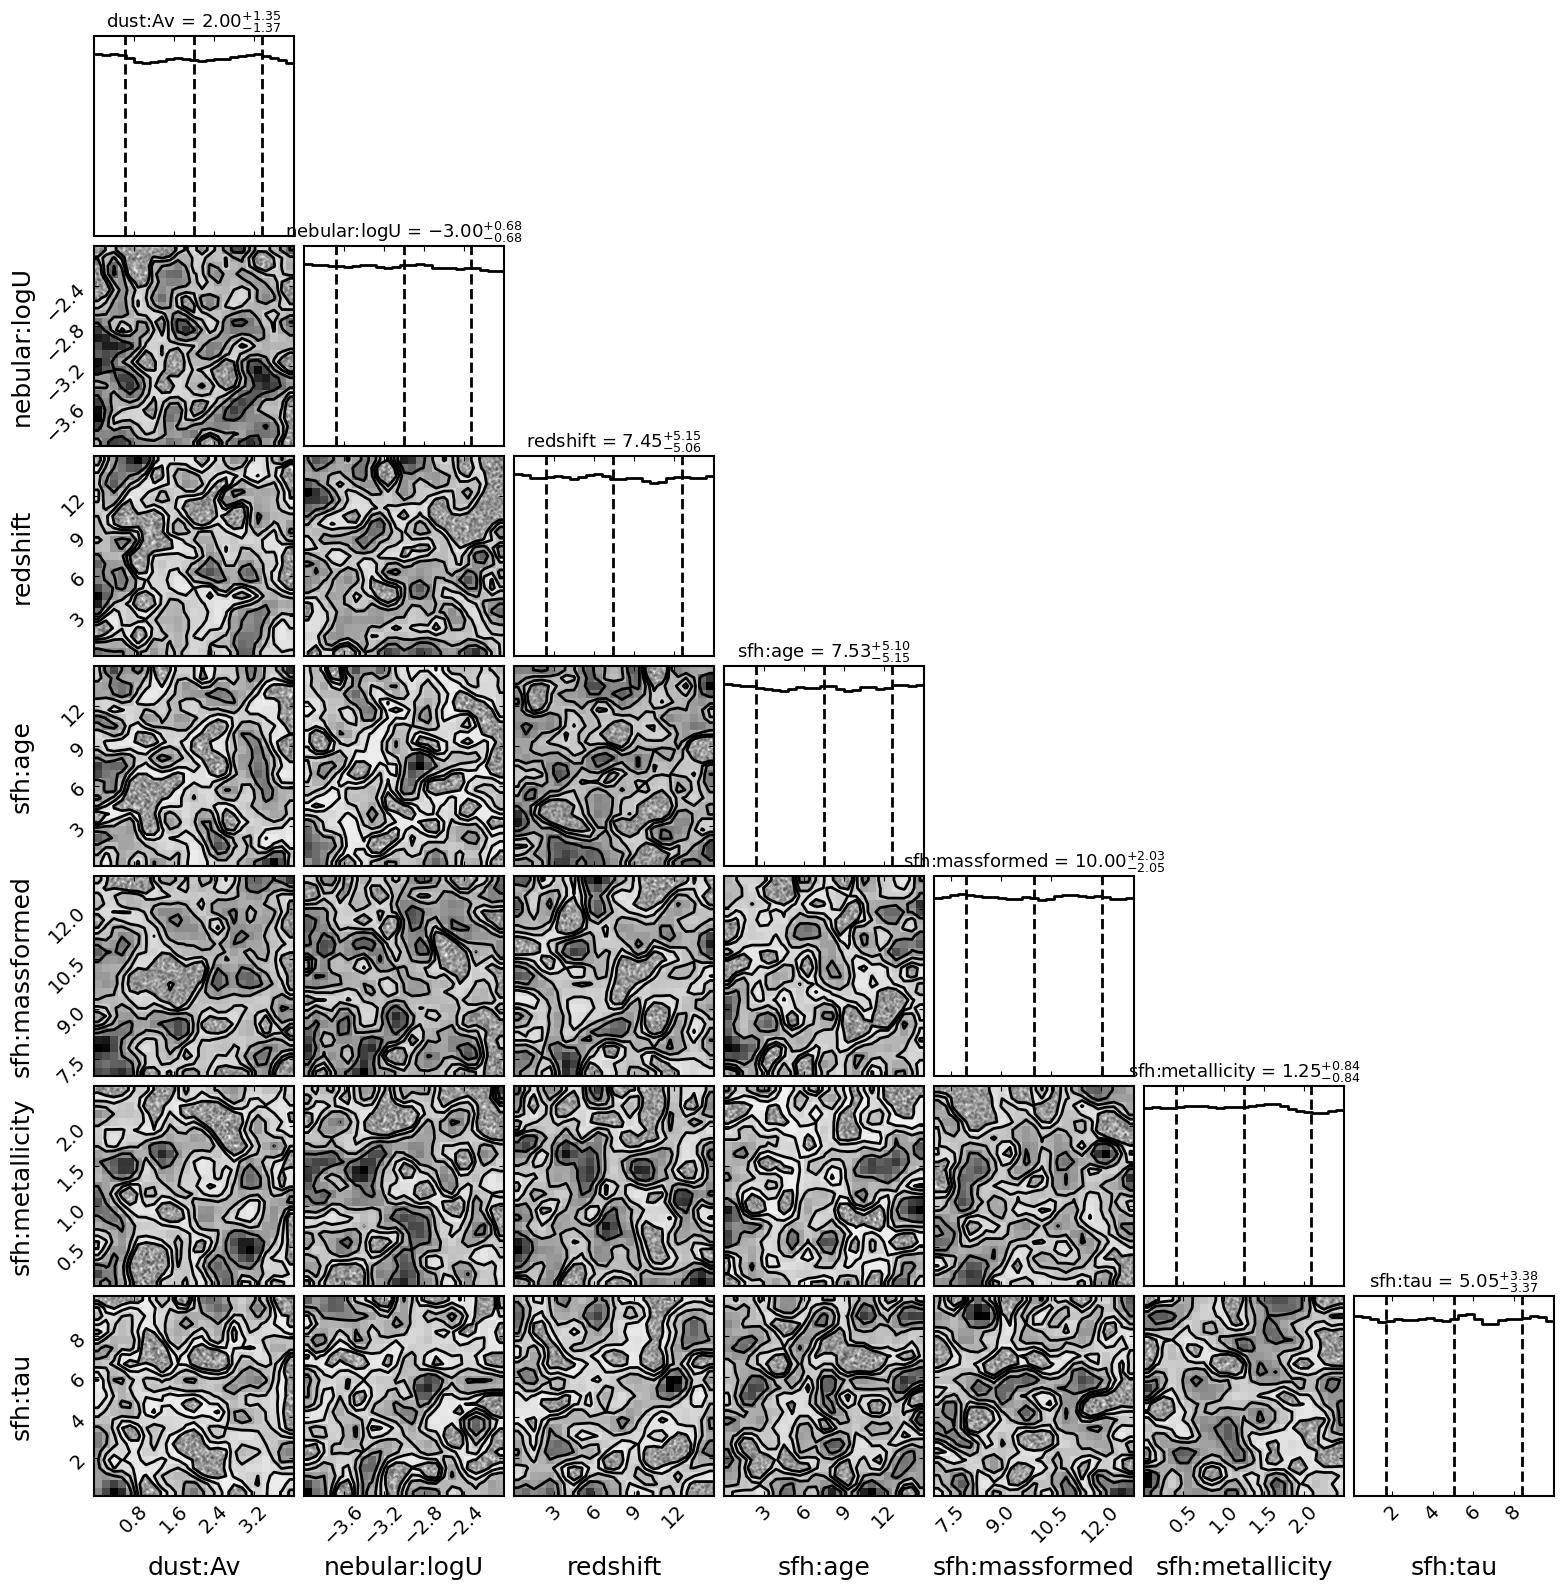

In [30]:
fig = fit.plot_corner(save=False, show=True)

In [30]:
import os
import numpy as np

filter_dir = "my_filters"
for f in os.listdir(filter_dir):
    if f.endswith(".res"):
        path = os.path.join(filter_dir, f)
        try:
            data = np.loadtxt(path)
            if data.size == 0:
                print(f"❌ 文件为空: {f}")
            else:
                print(f"✅ 文件正常: {f} (行数: {data.shape[0]})")
        except:
            print(f"❌ 文件格式损坏 (可能是HTML): {f}")

✅ 文件正常: F300M.res (行数: 455)
✅ 文件正常: F070W.res (行数: 201)
✅ 文件正常: F182M.res (行数: 382)
✅ 文件正常: F115W.res (行数: 340)
✅ 文件正常: F775W.res (行数: 2264)
✅ 文件正常: F606W.res (行数: 2715)
✅ 文件正常: F200W.res (行数: 609)
✅ 文件正常: F105W.res (行数: 532)
✅ 文件正常: F125W.res (行数: 1098)
✅ 文件正常: F277W.res (行数: 804)
✅ 文件正常: F850LP.res (行数: 3146)
✅ 文件正常: F430M.res (行数: 331)
✅ 文件正常: F410M.res (行数: 629)
✅ 文件正常: F444W.res (行数: 1027)
✅ 文件正常: F150W.res (行数: 445)
✅ 文件正常: F356W.res (行数: 916)
✅ 文件正常: F090W.res (行数: 253)
✅ 文件正常: F210M.res (行数: 335)
✅ 文件正常: F435W.res (行数: 1454)
✅ 文件正常: F1280W.res (行数: 609)
✅ 文件正常: F162M.res (行数: 294)
✅ 文件正常: F770W.res (行数: 539)
✅ 文件正常: F460M.res (行数: 380)
✅ 文件正常: F335M.res (行数: 557)
✅ 文件正常: F160W.res (行数: 532)
✅ 文件正常: F140W.res (行数: 741)
✅ 文件正常: F814W.res (行数: 6260)


In [ ]:
import os
import requests

filter_dir = "my_filters"
if not os.path.exists(filter_dir):
    os.makedirs(filter_dir)

# 你的原始滤光片列表
raw_names = [str(n).upper() for n in filter_names]
valid_filter_names = []  # 记录下载成功的名称
valid_filter_paths = []  # 记录对应的本地路径

print("正在尝试下载 HST 和 JWST 滤光片...")

for f_name in raw_names:
    save_path = os.path.join(os.getcwd(), filter_dir, f"{f_name}.res")

    # 按照优先级尝试不同的 SVO 路径
    possible_urls = [
        f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id=JWST/NIRCam.{f_name}",
        f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id=HST/ACS_WFC.{f_name}",
        f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id=HST/WFC3_IR.{f_name}",
        f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id=JWST/MIRI.{f_name}",
        f"https://svo2.cab.inta-csic.es/theory/fps/getdata.php?format=ascii&id=HST/WFPC2.{f_name}"
    ]

    success = False
    for url in possible_urls:
        try:
            r = requests.get(url, timeout=5)
            if r.status_code == 200 and len(r.text) > 200 and "No filter found" not in r.text:
                with open(save_path, "w") as f:
                    f.write(r.text)
                valid_filter_names.append(f_name)
                valid_filter_paths.append(save_path)
                print(f"✅ 已获取: {f_name}")
                success = True
                break
        except:
            continue

    if not success:
        print(f"❌ 跳过: {f_name} (在 SVO 常见路径中未找到)")

print(f"\n下载完成！共保留 {len(valid_filter_names)} 个有效滤光片。")

正在尝试下载 HST 和 JWST 滤光片...
✅ 已获取: F070W
✅ 已获取: F090W
✅ 已获取: F115W
✅ 已获取: F150W
✅ 已获取: F162M
✅ 已获取: F182M
✅ 已获取: F200W
✅ 已获取: F210M
✅ 已获取: F277W
✅ 已获取: F300M
✅ 已获取: F335M
✅ 已获取: F356W
✅ 已获取: F410M
✅ 已获取: F430M
✅ 已获取: F444W
✅ 已获取: F460M
✅ 已获取: F770W
✅ 已获取: F1280W
✅ 已获取: F435W
✅ 已获取: F606W
✅ 已获取: F775W
✅ 已获取: F814W
✅ 已获取: F850LP
✅ 已获取: F105W
✅ 已获取: F125W
✅ 已获取: F140W
✅ 已获取: F160W

下载完成！共保留 27 个有效滤光片。
